<a href="https://colab.research.google.com/github/Math-BUG/INF-494/blob/main/01_dbscan_nvcc_drop_core_points.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# DBSCAN CUDA C++/NVCC - Drop de core points

Este notebook usa o protocolo comum de `data/manifest.csv` e compara duas familias de aproximacao:

1. drop deterministico/hash de core points (`keep_100`, `keep_75`, `keep_50`, `keep_25`);
2. representantes espaciais por `cell` em datasets 2D (`cuda_cpp_grid_reps_K1`, `K2`, `K4`).

A estrategia por `grid` divide o espaco normalizado 2D em celulas de lado `eps` e mantem ate `K` core points por celula. A ideia e preservar cobertura espacial em regioes densas, reduzindo o risco de remover uma regiao inteira como pode acontecer no drop por hash. Essa otimizacao inicial e restrita a `d == 2`.

In [1]:
# Diagnostico do ambiente do Colab.
# Ative GPU em: Ambiente de execucao > Alterar tipo de ambiente de execucao > GPU.
!nvidia-smi
!nvcc --version
!which nvprof || echo "nvprof nao encontrado"

Mon Jun  8 07:21:07 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   37C    P8              9W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [2]:
import os
import re
import time
import subprocess
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.cluster import DBSCAN as SklearnDBSCAN
from sklearn.datasets import make_blobs, make_moons
from sklearn.decomposition import PCA
from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score
from sklearn.neighbors import NearestNeighbors

SEED = 42
np.random.seed(SEED)

# Use Google Drive para persistir data/ e results/ entre notebooks e runtimes do Colab.
# Se nao estiver no Colab, o codigo cai automaticamente para o diretorio local.
USE_GOOGLE_DRIVE = True
DRIVE_PROJECT_DIR = Path("/content/drive/MyDrive/INF494_DBSCAN")

BASE_DIR = Path(".")
if USE_GOOGLE_DRIVE:
    try:
        from google.colab import drive
        drive.mount("/content/drive")
        BASE_DIR = DRIVE_PROJECT_DIR
    except Exception as exc:
        print("Google Drive nao montado; usando diretorio local.")
        print("Motivo:", repr(exc))
        BASE_DIR = Path(".")

DATA_DIR = BASE_DIR / "data"
RESULTS_DIR = BASE_DIR / "results"
DATA_DIR.mkdir(parents=True, exist_ok=True)
RESULTS_DIR.mkdir(parents=True, exist_ok=True)
print("BASE_DIR:", BASE_DIR)
print("DATA_DIR:", DATA_DIR)
print("RESULTS_DIR:", RESULTS_DIR)

HAS_CUML = False
cp = None
CuMLDBSCAN = None

try:
    import cupy as cp
    from cuml.cluster import DBSCAN as CuMLDBSCAN
    HAS_CUML = True
    print("RAPIDS/cuML disponivel. Baseline: cuML.")
except Exception as exc:
    print("RAPIDS/cuML nao disponivel. Alternativa do baseline: sklearn CPU.")
    print("Motivo:", repr(exc))

print("HAS_CUML:", HAS_CUML)

Mounted at /content/drive
BASE_DIR: /content/drive/MyDrive/INF494_DBSCAN
DATA_DIR: /content/drive/MyDrive/INF494_DBSCAN/data
RESULTS_DIR: /content/drive/MyDrive/INF494_DBSCAN/results
RAPIDS/cuML disponivel. Baseline: cuML.
HAS_CUML: True


In [3]:
def normalize_minmax(X):
    X = np.asarray(X, dtype=np.float32)
    mn = X.min(axis=0)
    mx = X.max(axis=0)
    denom = mx - mn
    denom[denom == 0.0] = 1.0
    return ((X - mn) / denom).astype(np.float32)


def estimate_eps(X, min_samples=8, quantile=0.90, sample_size=5000, seed=SEED):
    rng = np.random.default_rng(seed)
    X = np.asarray(X, dtype=np.float32)
    if len(X) > sample_size:
        idx = rng.choice(len(X), size=sample_size, replace=False)
        Xs = X[idx]
    else:
        Xs = X
    nn = NearestNeighbors(n_neighbors=min_samples)
    nn.fit(Xs)
    dists, _ = nn.kneighbors(Xs)
    return float(np.quantile(dists[:, -1], quantile))


def relabel_consecutive(labels):
    labels = np.asarray(labels, dtype=np.int32)
    out = np.full(labels.shape, -1, dtype=np.int32)
    valid = [int(v) for v in np.unique(labels) if int(v) != -1]
    for new, old in enumerate(sorted(valid)):
        out[labels == old] = new
    return out


def count_clusters(labels):
    values = set(np.asarray(labels).tolist())
    values.discard(-1)
    return len(values)


def noise_percent(labels):
    return 100.0 * float(np.mean(np.asarray(labels) == -1))


def run_baseline_dbscan(X, eps, min_samples):
    X = np.ascontiguousarray(X.astype(np.float32))
    start = time.time()
    if HAS_CUML:
        X_gpu = cp.asarray(X)
        model = CuMLDBSCAN(eps=float(eps), min_samples=int(min_samples))
        labels_gpu = model.fit_predict(X_gpu)
        cp.cuda.Stream.null.synchronize()
        labels = cp.asnumpy(labels_gpu).astype(np.int32)
        backend = "cuML"
    else:
        model = SklearnDBSCAN(eps=float(eps), min_samples=int(min_samples), n_jobs=-1)
        labels = model.fit_predict(X).astype(np.int32)
        backend = "sklearn_cpu"
    elapsed = time.time() - start
    return relabel_consecutive(labels), elapsed, backend


def parse_key_values_stdout(stdout):
    metrics = {}
    for key, value in re.findall(r"([A-Za-z0-9_]+)=([^\s]+)", stdout):
        clean = value.strip().rstrip(",")
        try:
            if re.fullmatch(r"[-+]?\d+", clean):
                metrics[key] = int(clean)
            else:
                metrics[key] = float(clean)
        except ValueError:
            metrics[key] = clean
    return metrics


def run_cuda_binary(cmd):
    start = time.time()
    completed = subprocess.run(cmd, check=True, capture_output=True, text=True)
    wall_time = time.time() - start
    return completed.stdout, wall_time


def print_table(df, title):
    print(title)
    print(df.where(pd.notna(df), "N/A").to_string(index=False))


def plot_2d(X, labels, title):
    if X.shape[1] == 2:
        X2 = X[:, :2]
        xlab, ylab = "x1", "x2"
    else:
        X2 = PCA(n_components=2, random_state=SEED).fit_transform(X)
        xlab, ylab = "PCA1", "PCA2"
    plt.figure(figsize=(6, 5))
    plt.scatter(X2[:, 0], X2[:, 1], c=labels, s=8, cmap="tab20", alpha=0.85, linewidths=0)
    plt.title(title)
    plt.xlabel(xlab)
    plt.ylabel(ylab)
    plt.tight_layout()
    plt.show()

def make_controlled_dataset(name, n_samples, seed=SEED, n_features_32d=32):
    rng = np.random.default_rng(seed)
    if name == "dense_blobs_2d":
        X, y = make_blobs(n_samples=n_samples, centers=[(-3, -3), (-3, 3), (3, -3), (3, 3)], cluster_std=0.18, random_state=seed)
    elif name == "heterogeneous_blobs_2d":
        n1 = int(0.45 * n_samples)
        n2 = int(0.35 * n_samples)
        n3 = n_samples - n1 - n2
        X1, _ = make_blobs(n_samples=n1, centers=[(-4, 0)], cluster_std=0.08, random_state=seed + 1)
        X2, _ = make_blobs(n_samples=n2, centers=[(0, 0)], cluster_std=0.25, random_state=seed + 2)
        X3, _ = make_blobs(n_samples=n3, centers=[(4, 0)], cluster_std=0.65, random_state=seed + 3)
        X = np.vstack([X1, X2, X3])
        y = np.concatenate([np.zeros(n1, dtype=np.int32), np.ones(n2, dtype=np.int32), np.full(n3, 2, dtype=np.int32)])
    elif name == "dense_blobs_noise_2d":
        n_noise = int(0.20 * n_samples)
        n_blob = n_samples - n_noise
        X_blob, y_blob = make_blobs(n_samples=n_blob, centers=[(-3, -3), (-3, 3), (3, -3), (3, 3)], cluster_std=0.20, random_state=seed)
        noise = rng.uniform(low=-5.5, high=5.5, size=(n_noise, 2))
        X = np.vstack([X_blob, noise])
        y = np.concatenate([y_blob.astype(np.int32), np.full(n_noise, -1, dtype=np.int32)])
    elif name == "moons_2d":
        X, y = make_moons(n_samples=n_samples, noise=0.045, random_state=seed)
    elif name == "blobs_32d":
        X, y = make_blobs(n_samples=n_samples, centers=6, n_features=n_features_32d, cluster_std=0.45, random_state=seed)
    else:
        raise ValueError(f"Fallback local so cobre datasets sinteticos. Dataset recebido: {name}")
    return normalize_minmax(X), np.asarray(y, dtype=np.int32)


def load_dataset_from_manifest(dataset_name, n_samples, run_mode="benchmark", allow_local_debug_fallback=True):
    manifest_path = DATA_DIR / "manifest.csv"
    if manifest_path.exists():
        manifest = pd.read_csv(manifest_path)
        rows = manifest[(manifest["dataset_name"] == dataset_name) & (manifest["n_samples"] == int(n_samples))]
        if rows.empty:
            available = manifest[["dataset_name", "n_samples"]].drop_duplicates().to_string(index=False)
            raise ValueError(
                f"Dataset {dataset_name} com n_samples={n_samples} nao esta no manifest. "
                f"Execute o notebook 00 ou escolha uma entrada existente.\nEntradas disponiveis:\n{available}"
            )
        row = rows.iloc[0].to_dict()
        data_path = Path(row["data_path"])
        label_path = Path(row["label_path"])
        if not data_path.exists() or not label_path.exists():
            raise FileNotFoundError(
                f"Arquivos do dataset nao encontrados: {data_path} / {label_path}. "
                "Execute primeiro o notebook 00_datasets_e_configuracao.ipynb no Colab."
            )
        n = int(row["n_samples"])
        d = int(row["n_features"])
        X = np.fromfile(data_path, dtype=np.float32).reshape(n, d)
        y_true = np.load(label_path).astype(np.int32)
        return {
            "X": np.ascontiguousarray(X),
            "y_true": y_true,
            "EPS": float(row["eps"]),
            "MIN_SAMPLES": int(row["min_samples"]),
            "INPUT_BIN": str(data_path),
            "N": n,
            "D": d,
            "metadata": row,
            "loaded_from_manifest": True,
        }

    message = (
        "data/manifest.csv nao encontrado. Execute primeiro o notebook "
        "00_datasets_e_configuracao.ipynb para gerar datasets comuns."
    )
    if not allow_local_debug_fallback:
        raise FileNotFoundError(message)
    print(message)
    print("Usando fallback local apenas para depuracao. Resultados finais devem usar o manifest comum.")
    fallback_n = 4000 if run_mode == "quick" else min(int(n_samples), 4000)
    X, y_true = make_controlled_dataset(dataset_name, fallback_n)
    X = np.ascontiguousarray(X.astype(np.float32))
    eps = estimate_eps(X, min_samples=8, quantile=0.90, sample_size=5000)
    input_bin = f"debug_{dataset_name}_{fallback_n}_f32.bin"
    X.tofile(input_bin)
    return {
        "X": X,
        "y_true": y_true,
        "EPS": eps,
        "MIN_SAMPLES": 8,
        "INPUT_BIN": input_bin,
        "N": int(X.shape[0]),
        "D": int(X.shape[1]),
        "metadata": {
            "dataset_name": dataset_name,
            "n_samples": int(X.shape[0]),
            "n_features": int(X.shape[1]),
            "tipo": "debug_local",
            "observacao": "Fallback local; nao usar em resultado final.",
        },
        "loaded_from_manifest": False,
    }

In [4]:
# Celula padrao de selecao do dataset comum.
# Primeiro teste: mantenha RUN_MODE="quick" e N_SAMPLES=4000, que e o padrao gerado pelo notebook 00.
# Para resultados finais: rode o notebook 00 em RUN_MODE="benchmark" e depois use N_SAMPLES=10000/25000/50000 aqui.
DATASET_NAME = "heterogeneous_blobs_2d"
N_SAMPLES = 4000
RUN_MODE = "quick"  # use "benchmark" e N_SAMPLES = 10000 depois de gerar o manifest benchmark no notebook 00
ALLOW_LOCAL_DEBUG_FALLBACK = True

print("Datasets recomendados para este notebook:", ['heterogeneous_blobs_2d', 'dense_blobs_2d', 'real_covtype_sample'])

loaded = load_dataset_from_manifest(
    DATASET_NAME,
    N_SAMPLES,
    run_mode=RUN_MODE,
    allow_local_debug_fallback=ALLOW_LOCAL_DEBUG_FALLBACK,
)

X = loaded["X"]
y_true = loaded["y_true"]
EPS = loaded["EPS"]
MIN_SAMPLES = loaded["MIN_SAMPLES"]
INPUT_BIN = loaded["INPUT_BIN"]
N = loaded["N"]
D = loaded["D"]
META = loaded["metadata"]

print("Dataset ativo:", DATASET_NAME)
print("Carregado do manifest:", loaded["loaded_from_manifest"])
print("Shape:", X.shape)
print("eps:", EPS)
print("min_samples:", MIN_SAMPLES)
print("INPUT_BIN:", INPUT_BIN)

Datasets recomendados para este notebook: ['heterogeneous_blobs_2d', 'dense_blobs_2d', 'real_covtype_sample']
Dataset ativo: heterogeneous_blobs_2d
Carregado do manifest: True
Shape: (4000, 2)
eps: 0.0194469732363999
min_samples: 8
INPUT_BIN: /content/drive/MyDrive/INF494_DBSCAN/data/heterogeneous_blobs_2d_4000_f32.bin


In [5]:
%%writefile dbscan_drop_core.cu
#include <stdio.h>
#include <stdlib.h>
#include <stdint.h>
#include <math.h>
#include <fstream>
#include <vector>
#include <string>

#define CUDA_CHECK(call) do { \
    cudaError_t err = call; \
    if (err != cudaSuccess) { \
        printf("CUDA error %s:%d: %s\n", __FILE__, __LINE__, cudaGetErrorString(err)); \
        exit(1); \
    } \
} while(0)

__device__ unsigned int hash_u32(unsigned int x) {
    x ^= x >> 16;
    x *= 0x7feb352dU;
    x ^= x >> 15;
    x *= 0x846ca68bU;
    x ^= x >> 16;
    return x;
}

__device__ int find_root(int* parent, int i) {
    int root = i;
    while (root != parent[root]) root = parent[root];
    return root;
}

__global__ void find_cores(const float* X, int* is_core, int* neighbor_counts, int n, int d, float eps_sq, int min_pts) {
    int i = blockIdx.x * blockDim.x + threadIdx.x;
    if (i >= n) return;

    int neighbors = 0;
    for (int j = 0; j < n; j++) {
        float dist_sq = 0.0f;
        for (int f = 0; f < d; f++) {
            float diff = X[i * d + f] - X[j * d + f];
            dist_sq += diff * diff;
            if (dist_sq > eps_sq) break;
        }
        if (dist_sq <= eps_sq) {
            neighbors++;
            if (neighbors >= min_pts) break;
        }
    }
    neighbor_counts[i] = neighbors;
    is_core[i] = (neighbors >= min_pts) ? 1 : 0;
}

__global__ void init_keep_and_parent(const int* is_core, int* keep_core, int* parent, int n, int keep_per_million, unsigned int seed) {
    int i = blockIdx.x * blockDim.x + threadIdx.x;
    if (i >= n) return;

    parent[i] = i;
    int keep = 0;
    if (is_core[i]) {
        if (keep_per_million >= 1000000) {
            keep = 1;
        } else {
            unsigned int h = hash_u32((unsigned int)i ^ seed);
            keep = ((int)(h % 1000000U) < keep_per_million) ? 1 : 0;
        }
    }
    keep_core[i] = keep;
}

__global__ void connect_cores(const float* X, const int* keep_core, int* parent, int n, int d, float eps_sq) {
    int i = blockIdx.x * blockDim.x + threadIdx.x;
    if (i >= n || !keep_core[i]) return;

    for (int j = i + 1; j < n; j++) {
        if (!keep_core[j]) continue;

        float dist_sq = 0.0f;
        for (int f = 0; f < d; f++) {
            float diff = X[i * d + f] - X[j * d + f];
            dist_sq += diff * diff;
            if (dist_sq > eps_sq) break;
        }

        if (dist_sq <= eps_sq) {
            int root_i = find_root(parent, i);
            int root_j = find_root(parent, j);
            while (root_i != root_j) {
                if (root_i < root_j) {
                    int old = atomicCAS(&parent[root_j], root_j, root_i);
                    if (old == root_j) break;
                    root_j = find_root(parent, old);
                } else {
                    int old = atomicCAS(&parent[root_i], root_i, root_j);
                    if (old == root_i) break;
                    root_i = find_root(parent, old);
                }
            }
        }
    }
}

__global__ void flatten_parents(int* parent, int n) {
    int i = blockIdx.x * blockDim.x + threadIdx.x;
    if (i >= n) return;
    int root = i;
    while (root != parent[root]) root = parent[root];
    parent[i] = root;
}

__global__ void assign_borders_nearest(const float* X, const int* keep_core, const int* parent, int* labels, int n, int d, float eps_sq) {
    int i = blockIdx.x * blockDim.x + threadIdx.x;
    if (i >= n) return;

    if (keep_core[i]) {
        labels[i] = parent[i];
        return;
    }

    int best_label = -1;
    float best_dist_sq = eps_sq;
    int found = 0;

    for (int j = 0; j < n; j++) {
        if (!keep_core[j]) continue;

        float dist_sq = 0.0f;
        for (int f = 0; f < d; f++) {
            float diff = X[i * d + f] - X[j * d + f];
            dist_sq += diff * diff;
            if (dist_sq > eps_sq) break;
        }

        if (dist_sq <= eps_sq && (!found || dist_sq < best_dist_sq)) {
            found = 1;
            best_dist_sq = dist_sq;
            best_label = parent[j];
        }
    }
    labels[i] = best_label;
}

int main(int argc, char** argv) {
    if (argc < 9) {
        printf("Usage: %s input.bin output_labels.bin n d eps min_pts keep_per_million seed\n", argv[0]);
        return 1;
    }

    std::string input_path = argv[1];
    std::string output_path = argv[2];
    int n = atoi(argv[3]);
    int d = atoi(argv[4]);
    float eps = (float)atof(argv[5]);
    int min_pts = atoi(argv[6]);
    int keep_per_million = atoi(argv[7]);
    unsigned int seed = (unsigned int)atoi(argv[8]);
    float eps_sq = eps * eps;

    size_t data_count = (size_t)n * (size_t)d;
    std::vector<float> h_X(data_count);
    std::ifstream in(input_path, std::ios::binary);
    if (!in) { printf("Could not open input file.\n"); return 1; }
    in.read((char*)h_X.data(), data_count * sizeof(float));
    in.close();

    float* d_X = nullptr;
    int *d_is_core = nullptr, *d_keep_core = nullptr, *d_parent = nullptr, *d_labels = nullptr, *d_neighbor_counts = nullptr;

    CUDA_CHECK(cudaMalloc(&d_X, data_count * sizeof(float)));
    CUDA_CHECK(cudaMalloc(&d_is_core, n * sizeof(int)));
    CUDA_CHECK(cudaMalloc(&d_keep_core, n * sizeof(int)));
    CUDA_CHECK(cudaMalloc(&d_parent, n * sizeof(int)));
    CUDA_CHECK(cudaMalloc(&d_labels, n * sizeof(int)));
    CUDA_CHECK(cudaMalloc(&d_neighbor_counts, n * sizeof(int)));
    CUDA_CHECK(cudaMemcpy(d_X, h_X.data(), data_count * sizeof(float), cudaMemcpyHostToDevice));

    int threads = 256;
    int blocks = (n + threads - 1) / threads;

    cudaEvent_t e0, e1, e2, e3, e4, e5;
    cudaEventCreate(&e0); cudaEventCreate(&e1); cudaEventCreate(&e2); cudaEventCreate(&e3); cudaEventCreate(&e4); cudaEventCreate(&e5);

    cudaEventRecord(e0);
    find_cores<<<blocks, threads>>>(d_X, d_is_core, d_neighbor_counts, n, d, eps_sq, min_pts);
    CUDA_CHECK(cudaDeviceSynchronize());
    cudaEventRecord(e1);

    init_keep_and_parent<<<blocks, threads>>>(d_is_core, d_keep_core, d_parent, n, keep_per_million, seed);
    CUDA_CHECK(cudaDeviceSynchronize());
    cudaEventRecord(e2);

    connect_cores<<<blocks, threads>>>(d_X, d_keep_core, d_parent, n, d, eps_sq);
    CUDA_CHECK(cudaDeviceSynchronize());
    cudaEventRecord(e3);

    flatten_parents<<<blocks, threads>>>(d_parent, n);
    CUDA_CHECK(cudaDeviceSynchronize());
    cudaEventRecord(e4);

    assign_borders_nearest<<<blocks, threads>>>(d_X, d_keep_core, d_parent, d_labels, n, d, eps_sq);
    CUDA_CHECK(cudaDeviceSynchronize());
    cudaEventRecord(e5);
    cudaEventSynchronize(e5);

    float ms_find=0, ms_init=0, ms_connect=0, ms_flatten=0, ms_assign=0;
    cudaEventElapsedTime(&ms_find, e0, e1);
    cudaEventElapsedTime(&ms_init, e1, e2);
    cudaEventElapsedTime(&ms_connect, e2, e3);
    cudaEventElapsedTime(&ms_flatten, e3, e4);
    cudaEventElapsedTime(&ms_assign, e4, e5);

    std::vector<int> h_labels(n), h_is_core(n), h_keep_core(n);
    CUDA_CHECK(cudaMemcpy(h_labels.data(), d_labels, n * sizeof(int), cudaMemcpyDeviceToHost));
    CUDA_CHECK(cudaMemcpy(h_is_core.data(), d_is_core, n * sizeof(int), cudaMemcpyDeviceToHost));
    CUDA_CHECK(cudaMemcpy(h_keep_core.data(), d_keep_core, n * sizeof(int), cudaMemcpyDeviceToHost));

    int n_core = 0, n_keep = 0, n_noise = 0;
    for (int i = 0; i < n; i++) {
        n_core += h_is_core[i];
        n_keep += h_keep_core[i];
        if (h_labels[i] == -1) n_noise++;
    }

    std::ofstream out(output_path, std::ios::binary);
    out.write((char*)h_labels.data(), n * sizeof(int));
    out.close();

    printf("n=%d d=%d eps=%f min_pts=%d keep_per_million=%d\n", n, d, eps, min_pts, keep_per_million);
    printf("core_points=%d kept_core_points=%d noise=%d\n", n_core, n_keep, n_noise);
    printf("time_find=%.6f time_init=%.6f time_connect=%.6f time_flatten=%.6f time_assign=%.6f total=%.6f seconds\n",
           ms_find/1000.0f, ms_init/1000.0f, ms_connect/1000.0f, ms_flatten/1000.0f, ms_assign/1000.0f,
           (ms_find + ms_init + ms_connect + ms_flatten + ms_assign)/1000.0f);

    cudaFree(d_X); cudaFree(d_is_core); cudaFree(d_keep_core); cudaFree(d_parent); cudaFree(d_labels); cudaFree(d_neighbor_counts);
    return 0;
}

Writing dbscan_drop_core.cu


In [6]:
%%writefile dbscan_grid_reps_2d.cu
#include <stdio.h>
#include <stdlib.h>
#include <stdint.h>
#include <math.h>
#include <fstream>
#include <vector>
#include <string>

#define CUDA_CHECK(call) do { \
    cudaError_t err = call; \
    if (err != cudaSuccess) { \
        printf("CUDA error %s:%d: %s\n", __FILE__, __LINE__, cudaGetErrorString(err)); \
        exit(1); \
    } \
} while(0)

__device__ int find_root(int* parent, int i) {
    int root = i;
    while (root != parent[root]) root = parent[root];
    return root;
}

__device__ int point_cell_2d(const float* X, int i, int grid_dim, float cell_size) {
    int cx = (int)floorf(X[i * 2 + 0] / cell_size);
    int cy = (int)floorf(X[i * 2 + 1] / cell_size);
    if (cx < 0) cx = 0;
    if (cy < 0) cy = 0;
    if (cx >= grid_dim) cx = grid_dim - 1;
    if (cy >= grid_dim) cy = grid_dim - 1;
    return cy * grid_dim + cx;
}

__global__ void count_cells(const float* X, int* point_cell, int* cell_counts, int n, int grid_dim, float cell_size) {
    int i = blockIdx.x * blockDim.x + threadIdx.x;
    if (i >= n) return;
    int cell = point_cell_2d(X, i, grid_dim, cell_size);
    point_cell[i] = cell;
    atomicAdd(&cell_counts[cell], 1);
}

__global__ void fill_cell_indices(const int* point_cell, int* cell_counts_work, const int* cell_start, int* sorted_indices, int n) {
    int i = blockIdx.x * blockDim.x + threadIdx.x;
    if (i >= n) return;
    int cell = point_cell[i];
    int pos = atomicAdd(&cell_counts_work[cell], 1);
    sorted_indices[cell_start[cell] + pos] = i;
}

__global__ void init_parent_keep(int* parent, int* keep_core, int n) {
    int i = blockIdx.x * blockDim.x + threadIdx.x;
    if (i >= n) return;
    parent[i] = i;
    keep_core[i] = 0;
}

__global__ void find_cores_grid_f32(
    const float* X,
    const int* cell_start,
    const int* cell_end,
    const int* sorted_indices,
    int* is_core,
    int n,
    int grid_dim,
    float cell_size,
    float eps_sq,
    int min_pts
) {
    int i = blockIdx.x * blockDim.x + threadIdx.x;
    if (i >= n) return;

    int cell = point_cell_2d(X, i, grid_dim, cell_size);
    int cx = cell % grid_dim;
    int cy = cell / grid_dim;
    int neighbors = 0;

    for (int dy = -1; dy <= 1; dy++) {
        int ny = cy + dy;
        if (ny < 0 || ny >= grid_dim) continue;
        for (int dx = -1; dx <= 1; dx++) {
            int nx = cx + dx;
            if (nx < 0 || nx >= grid_dim) continue;
            int c = ny * grid_dim + nx;
            for (int p = cell_start[c]; p < cell_end[c]; p++) {
                int j = sorted_indices[p];
                float dx0 = X[i * 2 + 0] - X[j * 2 + 0];
                float dx1 = X[i * 2 + 1] - X[j * 2 + 1];
                float dist_sq = dx0 * dx0 + dx1 * dx1;
                if (dist_sq <= eps_sq) {
                    neighbors++;
                    if (neighbors >= min_pts) {
                        is_core[i] = 1;
                        return;
                    }
                }
            }
        }
    }
    is_core[i] = 0;
}

__global__ void choose_representatives_grid(
    const int* is_core,
    const int* cell_start,
    const int* cell_end,
    const int* sorted_indices,
    int* keep_core,
    int num_cells,
    int reps_per_cell
) {
    int cell = blockIdx.x * blockDim.x + threadIdx.x;
    if (cell >= num_cells) return;
    int kept = 0;
    for (int p = cell_start[cell]; p < cell_end[cell]; p++) {
        int idx = sorted_indices[p];
        if (is_core[idx] && kept < reps_per_cell) {
            keep_core[idx] = 1;
            kept++;
        }
    }
}

__global__ void connect_cores_grid_f32(
    const float* X,
    const int* keep_core,
    const int* cell_start,
    const int* cell_end,
    const int* sorted_indices,
    int* parent,
    int n,
    int grid_dim,
    float cell_size,
    float eps_sq
) {
    int i = blockIdx.x * blockDim.x + threadIdx.x;
    if (i >= n || !keep_core[i]) return;

    int cell = point_cell_2d(X, i, grid_dim, cell_size);
    int cx = cell % grid_dim;
    int cy = cell / grid_dim;

    for (int dy = -1; dy <= 1; dy++) {
        int ny = cy + dy;
        if (ny < 0 || ny >= grid_dim) continue;
        for (int dx = -1; dx <= 1; dx++) {
            int nx = cx + dx;
            if (nx < 0 || nx >= grid_dim) continue;
            int c = ny * grid_dim + nx;
            for (int p = cell_start[c]; p < cell_end[c]; p++) {
                int j = sorted_indices[p];
                if (j <= i || !keep_core[j]) continue;
                float dx0 = X[i * 2 + 0] - X[j * 2 + 0];
                float dx1 = X[i * 2 + 1] - X[j * 2 + 1];
                float dist_sq = dx0 * dx0 + dx1 * dx1;
                if (dist_sq <= eps_sq) {
                    int root_i = find_root(parent, i);
                    int root_j = find_root(parent, j);
                    while (root_i != root_j) {
                        if (root_i < root_j) {
                            int old = atomicCAS(&parent[root_j], root_j, root_i);
                            if (old == root_j) break;
                            root_j = find_root(parent, old);
                        } else {
                            int old = atomicCAS(&parent[root_i], root_i, root_j);
                            if (old == root_i) break;
                            root_i = find_root(parent, old);
                        }
                    }
                }
            }
        }
    }
}

__global__ void flatten_parents(int* parent, int n) {
    int i = blockIdx.x * blockDim.x + threadIdx.x;
    if (i >= n) return;
    int root = i;
    while (root != parent[root]) root = parent[root];
    parent[i] = root;
}

__global__ void assign_borders_grid_f32(
    const float* X,
    const int* keep_core,
    const int* parent,
    const int* cell_start,
    const int* cell_end,
    const int* sorted_indices,
    int* labels,
    int n,
    int grid_dim,
    float cell_size,
    float eps_sq
) {
    int i = blockIdx.x * blockDim.x + threadIdx.x;
    if (i >= n) return;
    if (keep_core[i]) {
        labels[i] = parent[i];
        return;
    }

    int cell = point_cell_2d(X, i, grid_dim, cell_size);
    int cx = cell % grid_dim;
    int cy = cell / grid_dim;
    int best = -1;
    float best_d = eps_sq;
    int found = 0;

    for (int dy = -1; dy <= 1; dy++) {
        int ny = cy + dy;
        if (ny < 0 || ny >= grid_dim) continue;
        for (int dx = -1; dx <= 1; dx++) {
            int nx = cx + dx;
            if (nx < 0 || nx >= grid_dim) continue;
            int c = ny * grid_dim + nx;
            for (int p = cell_start[c]; p < cell_end[c]; p++) {
                int j = sorted_indices[p];
                if (!keep_core[j]) continue;
                float dx0 = X[i * 2 + 0] - X[j * 2 + 0];
                float dx1 = X[i * 2 + 1] - X[j * 2 + 1];
                float dist_sq = dx0 * dx0 + dx1 * dx1;
                if (dist_sq <= eps_sq && (!found || dist_sq < best_d)) {
                    found = 1;
                    best_d = dist_sq;
                    best = parent[j];
                }
            }
        }
    }
    labels[i] = best;
}

float elapsed_s(cudaEvent_t a, cudaEvent_t b) {
    float ms = 0.0f;
    cudaEventElapsedTime(&ms, a, b);
    return ms / 1000.0f;
}

int main(int argc, char** argv) {
    if (argc < 8) {
        printf("Usage: %s input.bin output_labels.bin n d eps min_pts reps_per_cell\n", argv[0]);
        return 1;
    }
    std::string input_path = argv[1];
    std::string output_path = argv[2];
    int n = atoi(argv[3]);
    int d = atoi(argv[4]);
    float eps = (float)atof(argv[5]);
    int min_pts = atoi(argv[6]);
    int reps_per_cell = atoi(argv[7]);

    if (d != 2) {
        printf("status=ignorado motivo=grid_espacial_implementado_apenas_para_d_2 d=%d\n", d);
        return 2;
    }

    size_t count = (size_t)n * 2;
    std::vector<float> h_X(count);
    std::ifstream in(input_path, std::ios::binary);
    if (!in) { printf("Could not open input file.\n"); return 1; }
    in.read((char*)h_X.data(), count * sizeof(float));
    in.close();

    float cell_size = eps;
    if (cell_size <= 1e-7f) cell_size = 1e-7f;
    int grid_dim = (int)ceilf(1.0f / cell_size);
    if (grid_dim < 1) grid_dim = 1;
    int num_cells = grid_dim * grid_dim;
    float eps_sq = eps * eps;

    int threads = 256;
    int blocks_n = (n + threads - 1) / threads;
    int blocks_cells = (num_cells + threads - 1) / threads;

    float *d_X = nullptr;
    int *d_point_cell = nullptr, *d_cell_counts = nullptr, *d_cell_counts_work = nullptr;
    int *d_cell_start = nullptr, *d_cell_end = nullptr, *d_sorted_indices = nullptr;
    int *d_is_core = nullptr, *d_parent = nullptr, *d_keep_core = nullptr, *d_labels = nullptr;

    CUDA_CHECK(cudaMalloc(&d_X, count * sizeof(float)));
    CUDA_CHECK(cudaMalloc(&d_point_cell, n * sizeof(int)));
    CUDA_CHECK(cudaMalloc(&d_cell_counts, num_cells * sizeof(int)));
    CUDA_CHECK(cudaMalloc(&d_cell_counts_work, num_cells * sizeof(int)));
    CUDA_CHECK(cudaMalloc(&d_cell_start, num_cells * sizeof(int)));
    CUDA_CHECK(cudaMalloc(&d_cell_end, num_cells * sizeof(int)));
    CUDA_CHECK(cudaMalloc(&d_sorted_indices, n * sizeof(int)));
    CUDA_CHECK(cudaMalloc(&d_is_core, n * sizeof(int)));
    CUDA_CHECK(cudaMalloc(&d_parent, n * sizeof(int)));
    CUDA_CHECK(cudaMalloc(&d_keep_core, n * sizeof(int)));
    CUDA_CHECK(cudaMalloc(&d_labels, n * sizeof(int)));
    CUDA_CHECK(cudaMemcpy(d_X, h_X.data(), count * sizeof(float), cudaMemcpyHostToDevice));

    cudaEvent_t t0, t_grid1, t_find1, t_choose1, t_connect1, t_flatten1, t_assign1;
    cudaEventCreate(&t0); cudaEventCreate(&t_grid1); cudaEventCreate(&t_find1);
    cudaEventCreate(&t_choose1); cudaEventCreate(&t_connect1); cudaEventCreate(&t_flatten1); cudaEventCreate(&t_assign1);
    cudaEventRecord(t0);

    CUDA_CHECK(cudaMemset(d_cell_counts, 0, num_cells * sizeof(int)));
    count_cells<<<blocks_n, threads>>>(d_X, d_point_cell, d_cell_counts, n, grid_dim, cell_size);
    CUDA_CHECK(cudaDeviceSynchronize());

    std::vector<int> h_counts(num_cells), h_start(num_cells), h_end(num_cells);
    CUDA_CHECK(cudaMemcpy(h_counts.data(), d_cell_counts, num_cells * sizeof(int), cudaMemcpyDeviceToHost));
    int prefix = 0;
    for (int c = 0; c < num_cells; c++) {
        h_start[c] = prefix;
        prefix += h_counts[c];
        h_end[c] = prefix;
    }
    CUDA_CHECK(cudaMemcpy(d_cell_start, h_start.data(), num_cells * sizeof(int), cudaMemcpyHostToDevice));
    CUDA_CHECK(cudaMemcpy(d_cell_end, h_end.data(), num_cells * sizeof(int), cudaMemcpyHostToDevice));
    CUDA_CHECK(cudaMemset(d_cell_counts_work, 0, num_cells * sizeof(int)));
    fill_cell_indices<<<blocks_n, threads>>>(d_point_cell, d_cell_counts_work, d_cell_start, d_sorted_indices, n);
    CUDA_CHECK(cudaDeviceSynchronize());
    cudaEventRecord(t_grid1);

    find_cores_grid_f32<<<blocks_n, threads>>>(d_X, d_cell_start, d_cell_end, d_sorted_indices, d_is_core, n, grid_dim, cell_size, eps_sq, min_pts);
    CUDA_CHECK(cudaDeviceSynchronize());
    cudaEventRecord(t_find1);

    init_parent_keep<<<blocks_n, threads>>>(d_parent, d_keep_core, n);
    CUDA_CHECK(cudaDeviceSynchronize());
    choose_representatives_grid<<<blocks_cells, threads>>>(d_is_core, d_cell_start, d_cell_end, d_sorted_indices, d_keep_core, num_cells, reps_per_cell);
    CUDA_CHECK(cudaDeviceSynchronize());
    cudaEventRecord(t_choose1);

    connect_cores_grid_f32<<<blocks_n, threads>>>(d_X, d_keep_core, d_cell_start, d_cell_end, d_sorted_indices, d_parent, n, grid_dim, cell_size, eps_sq);
    CUDA_CHECK(cudaDeviceSynchronize());
    cudaEventRecord(t_connect1);

    flatten_parents<<<blocks_n, threads>>>(d_parent, n);
    CUDA_CHECK(cudaDeviceSynchronize());
    cudaEventRecord(t_flatten1);

    assign_borders_grid_f32<<<blocks_n, threads>>>(d_X, d_keep_core, d_parent, d_cell_start, d_cell_end, d_sorted_indices, d_labels, n, grid_dim, cell_size, eps_sq);
    CUDA_CHECK(cudaDeviceSynchronize());
    cudaEventRecord(t_assign1);
    cudaEventSynchronize(t_assign1);

    std::vector<int> h_labels(n), h_core(n), h_keep(n);
    CUDA_CHECK(cudaMemcpy(h_labels.data(), d_labels, n * sizeof(int), cudaMemcpyDeviceToHost));
    CUDA_CHECK(cudaMemcpy(h_core.data(), d_is_core, n * sizeof(int), cudaMemcpyDeviceToHost));
    CUDA_CHECK(cudaMemcpy(h_keep.data(), d_keep_core, n * sizeof(int), cudaMemcpyDeviceToHost));

    int n_core = 0, n_keep = 0, n_noise = 0;
    for (int i = 0; i < n; i++) {
        n_core += h_core[i];
        n_keep += h_keep[i];
        if (h_labels[i] == -1) n_noise++;
    }

    std::ofstream out(output_path, std::ios::binary);
    out.write((char*)h_labels.data(), n * sizeof(int));
    out.close();

    float time_grid = elapsed_s(t0, t_grid1);
    float time_find = elapsed_s(t_grid1, t_find1);
    float time_choose = elapsed_s(t_find1, t_choose1);
    float time_connect = elapsed_s(t_choose1, t_connect1);
    float time_flatten = elapsed_s(t_connect1, t_flatten1);
    float time_assign = elapsed_s(t_flatten1, t_assign1);
    float total = elapsed_s(t0, t_assign1);

    printf("status=ok mode=grid_reps K=%d n=%d d=%d eps=%f min_pts=%d grid_dim=%d num_cells=%d\n",
           reps_per_cell, n, d, eps, min_pts, grid_dim, num_cells);
    printf("core_points=%d kept_core_points=%d noise=%d\n", n_core, n_keep, n_noise);
    printf("time_grid_build=%.6f time_find=%.6f time_choose_reps=%.6f time_connect=%.6f time_flatten=%.6f time_assign=%.6f total=%.6f seconds\n",
           time_grid, time_find, time_choose, time_connect, time_flatten, time_assign, total);

    cudaFree(d_X); cudaFree(d_point_cell); cudaFree(d_cell_counts); cudaFree(d_cell_counts_work);
    cudaFree(d_cell_start); cudaFree(d_cell_end); cudaFree(d_sorted_indices);
    cudaFree(d_is_core); cudaFree(d_parent); cudaFree(d_keep_core); cudaFree(d_labels);
    return 0;
}

Writing dbscan_grid_reps_2d.cu


In [7]:
!nvcc dbscan_drop_core.cu -o dbscan_drop_core -O3
!nvcc dbscan_grid_reps_2d.cu -o dbscan_grid_reps_2d -O3

!if command -v nvprof >/dev/null 2>&1; then nvprof ./dbscan_drop_core {INPUT_BIN} nvprof_keep100_labels.bin {N} {D} {EPS} {MIN_SAMPLES} 1000000 {SEED}; else echo "nvprof nao encontrado; executando binario diretamente"; ./dbscan_drop_core {INPUT_BIN} nvprof_keep100_labels.bin {N} {D} {EPS} {MIN_SAMPLES} 1000000 {SEED}; fi

nvcc warning : Support for offline compilation for architectures prior to '<compute/sm/lto>_75' will be removed in a future release (Use -Wno-deprecated-gpu-targets to suppress warning).
nvcc warning : Support for offline compilation for architectures prior to '<compute/sm/lto>_75' will be removed in a future release (Use -Wno-deprecated-gpu-targets to suppress warning).
==9336== NVPROF is profiling process 9336, command: ./dbscan_drop_core /content/drive/MyDrive/INF494_DBSCAN/data/heterogeneous_blobs_2d_4000_f32.bin nvprof_keep100_labels.bin 4000 2 0.0194469732363999 8 1000000 42
n=4000 d=2 eps=0.019447 min_pts=8 keep_per_million=1000000
core_points=3600 kept_core_points=3600 noise=222
time_find=0.155690 time_init=0.000031 time_connect=0.009004 time_flatten=0.000040 time_assign=0.001630 total=0.166395 seconds
==9336== Profiling application: ./dbscan_drop_core /content/drive/MyDrive/INF494_DBSCAN/data/heterogeneous_blobs_2d_4000_f32.bin nvprof_keep100_labels.bin 4000 2 0.01944697323639

In [8]:
def empty_failure_row(dataset_name, n, d, version, status, motivo):
    return {
        "dataset_name": dataset_name,
        "n_samples": n,
        "n_features": d,
        "versao": version,
        "status": status,
        "motivo_falha": motivo,
        "keep_ratio_target": np.nan,
        "keep_ratio_real": np.nan,
        "core_points": np.nan,
        "kept_core_points": np.nan,
        "noise": np.nan,
        "noise_%": np.nan,
        "time_s_wall": np.nan,
        "total_cuda_event_s": np.nan,
        "time_grid_build": np.nan,
        "time_find": np.nan,
        "time_choose_reps": np.nan,
        "time_init": np.nan,
        "time_connect": np.nan,
        "time_flatten": np.nan,
        "time_assign": np.nan,
        "speedup_vs_baseline_wall": np.nan,
        "speedup_vs_cuda_keep100_event": np.nan,
        "speedup_vs_cuda_float32_event": np.nan,
        "clusters": np.nan,
        "ARI_vs_baseline": np.nan,
        "NMI_vs_baseline": np.nan,
    }


def executar_drop_core_dataset(dataset_name, n_samples):
    loaded_local = load_dataset_from_manifest(dataset_name, n_samples, run_mode=RUN_MODE, allow_local_debug_fallback=ALLOW_LOCAL_DEBUG_FALLBACK)
    Xl = loaded_local["X"]
    eps = loaded_local["EPS"]
    min_samples = loaded_local["MIN_SAMPLES"]
    input_bin = loaded_local["INPUT_BIN"]
    n = loaded_local["N"]
    d = loaded_local["D"]

    labels_baseline, time_baseline, backend = run_baseline_dbscan(Xl, eps, min_samples)
    baseline_version = f"baseline_{backend}"
    rows = [{
        "dataset_name": dataset_name,
        "n_samples": n,
        "n_features": d,
        "versao": baseline_version,
        "status": "ok",
        "motivo_falha": "",
        "keep_ratio_target": 1.0,
        "keep_ratio_real": np.nan,
        "core_points": np.nan,
        "kept_core_points": np.nan,
        "noise": int(np.sum(labels_baseline == -1)),
        "noise_%": noise_percent(labels_baseline),
        "time_s_wall": time_baseline,
        "total_cuda_event_s": np.nan,
        "time_grid_build": np.nan,
        "time_find": np.nan,
        "time_choose_reps": np.nan,
        "time_init": np.nan,
        "time_connect": np.nan,
        "time_flatten": np.nan,
        "time_assign": np.nan,
        "speedup_vs_baseline_wall": 1.0,
        "speedup_vs_cuda_keep100_event": np.nan,
        "speedup_vs_cuda_float32_event": np.nan,
        "clusters": count_clusters(labels_baseline),
        "ARI_vs_baseline": 1.0,
        "NMI_vs_baseline": 1.0,
    }]
    labels_by_version = {baseline_version: labels_baseline}

    for version, ratio in [("keep_100", 1.00), ("drop_keep_75", 0.75), ("drop_keep_50", 0.50), ("drop_keep_25", 0.25)]:
        full_version = f"cuda_cpp_{version}"
        out_file = f"{dataset_name}_{n}_{full_version}_labels.bin"
        keep_per_million = int(round(ratio * 1_000_000))
        cmd = ["./dbscan_drop_core", input_bin, out_file, str(n), str(d), str(eps), str(min_samples), str(keep_per_million), str(SEED)]
        stdout, wall_time = run_cuda_binary(cmd)
        print("\n---", full_version, "---")
        print(stdout)
        metrics = parse_key_values_stdout(stdout)
        labels = relabel_consecutive(np.fromfile(out_file, dtype=np.int32, count=n))
        labels_by_version[full_version] = labels
        core_points = int(metrics.get("core_points", 0))
        kept_core_points = int(metrics.get("kept_core_points", 0))
        rows.append({
            "dataset_name": dataset_name,
            "n_samples": n,
            "n_features": d,
            "versao": full_version,
            "status": "ok",
            "motivo_falha": "",
            "keep_ratio_target": ratio,
            "keep_ratio_real": kept_core_points / core_points if core_points else np.nan,
            "core_points": core_points,
            "kept_core_points": kept_core_points,
            "noise": int(metrics.get("noise", np.sum(labels == -1))),
            "noise_%": noise_percent(labels),
            "time_s_wall": wall_time,
            "total_cuda_event_s": float(metrics.get("total", np.nan)),
            "time_grid_build": np.nan,
            "time_find": float(metrics.get("time_find", np.nan)),
            "time_choose_reps": np.nan,
            "time_init": float(metrics.get("time_init", np.nan)),
            "time_connect": float(metrics.get("time_connect", np.nan)),
            "time_flatten": float(metrics.get("time_flatten", np.nan)),
            "time_assign": float(metrics.get("time_assign", np.nan)),
            "speedup_vs_baseline_wall": time_baseline / wall_time if wall_time > 0 else np.nan,
            "speedup_vs_cuda_keep100_event": np.nan,
            "speedup_vs_cuda_float32_event": np.nan,
            "clusters": count_clusters(labels),
            "ARI_vs_baseline": adjusted_rand_score(labels_baseline, labels),
            "NMI_vs_baseline": normalized_mutual_info_score(labels_baseline, labels),
        })

    if d != 2:
        for k in [1, 2, 4]:
            rows.append(empty_failure_row(dataset_name, n, d, f"cuda_cpp_grid_reps_K{k}", "ignorado", "grid espacial implementado apenas para d=2"))
    else:
        for k in [1, 2, 4]:
            version = f"cuda_cpp_grid_reps_K{k}"
            out_file = f"{dataset_name}_{n}_{version}_labels.bin"
            try:
                cmd = ["./dbscan_grid_reps_2d", input_bin, out_file, str(n), str(d), str(eps), str(min_samples), str(k)]
                stdout, wall_time = run_cuda_binary(cmd)
                print("\n---", version, "---")
                print(stdout)
                metrics = parse_key_values_stdout(stdout)
                labels = relabel_consecutive(np.fromfile(out_file, dtype=np.int32, count=n))
                labels_by_version[version] = labels
                core_points = int(metrics.get("core_points", 0))
                kept_core_points = int(metrics.get("kept_core_points", 0))
                rows.append({
                    "dataset_name": dataset_name,
                    "n_samples": n,
                    "n_features": d,
                    "versao": version,
                    "status": "ok",
                    "motivo_falha": "",
                    "keep_ratio_target": np.nan,
                    "keep_ratio_real": kept_core_points / core_points if core_points else np.nan,
                    "core_points": core_points,
                    "kept_core_points": kept_core_points,
                    "noise": int(metrics.get("noise", np.sum(labels == -1))),
                    "noise_%": noise_percent(labels),
                    "time_s_wall": wall_time,
                    "total_cuda_event_s": float(metrics.get("total", np.nan)),
                    "time_grid_build": float(metrics.get("time_grid_build", np.nan)),
                    "time_find": float(metrics.get("time_find", np.nan)),
                    "time_choose_reps": float(metrics.get("time_choose_reps", np.nan)),
                    "time_init": np.nan,
                    "time_connect": float(metrics.get("time_connect", np.nan)),
                    "time_flatten": float(metrics.get("time_flatten", np.nan)),
                    "time_assign": float(metrics.get("time_assign", np.nan)),
                    "speedup_vs_baseline_wall": time_baseline / wall_time if wall_time > 0 else np.nan,
                    "speedup_vs_cuda_keep100_event": np.nan,
                    "speedup_vs_cuda_float32_event": np.nan,
                    "clusters": count_clusters(labels),
                    "ARI_vs_baseline": adjusted_rand_score(labels_baseline, labels),
                    "NMI_vs_baseline": normalized_mutual_info_score(labels_baseline, labels),
                })
            except Exception as exc:
                rows.append(empty_failure_row(dataset_name, n, d, version, "falhou", str(exc)[:200]))

    df = pd.DataFrame(rows)
    keep100 = df.loc[df["versao"] == "cuda_cpp_keep_100", "total_cuda_event_s"]
    if len(keep100) and pd.notna(keep100.iloc[0]) and keep100.iloc[0] > 0:
        ref = float(keep100.iloc[0])
        mask = df["total_cuda_event_s"].notna() & (df["total_cuda_event_s"] > 0)
        df.loc[mask, "speedup_vs_cuda_keep100_event"] = ref / df.loc[mask, "total_cuda_event_s"]
        df.loc[mask, "speedup_vs_cuda_float32_event"] = ref / df.loc[mask, "total_cuda_event_s"]
    return df, labels_by_version, Xl


df_results, all_labels, X_plot = executar_drop_core_dataset(DATASET_NAME, N_SAMPLES)
output_csv = RESULTS_DIR / f"resultados_drop_core_points_{DATASET_NAME}_{int(df_results['n_samples'].iloc[0])}.csv"
df_results.to_csv(output_csv, index=False)
print_table(df_results.round(4), "Tabela final - drop de core points")
print("CSV salvo em:", output_csv)


--- cuda_cpp_keep_100 ---
n=4000 d=2 eps=0.019447 min_pts=8 keep_per_million=1000000
core_points=3600 kept_core_points=3600 noise=222
time_find=0.002144 time_init=0.000058 time_connect=0.011230 time_flatten=0.000056 time_assign=0.002066 total=0.015555 seconds


--- cuda_cpp_drop_keep_75 ---
n=4000 d=2 eps=0.019447 min_pts=8 keep_per_million=750000
core_points=3600 kept_core_points=2649 noise=239
time_find=0.001159 time_init=0.000027 time_connect=0.005290 time_flatten=0.000063 time_assign=0.001107 total=0.007647 seconds


--- cuda_cpp_drop_keep_50 ---
n=4000 d=2 eps=0.019447 min_pts=8 keep_per_million=500000
core_points=3600 kept_core_points=1753 noise=280
time_find=0.001039 time_init=0.000028 time_connect=0.003638 time_flatten=0.000031 time_assign=0.000760 total=0.005495 seconds


--- cuda_cpp_drop_keep_25 ---
n=4000 d=2 eps=0.019447 min_pts=8 keep_per_million=250000
core_points=3600 kept_core_points=874 noise=355
time_find=0.000985 time_init=0.000020 time_connect=0.002378 time_flatte

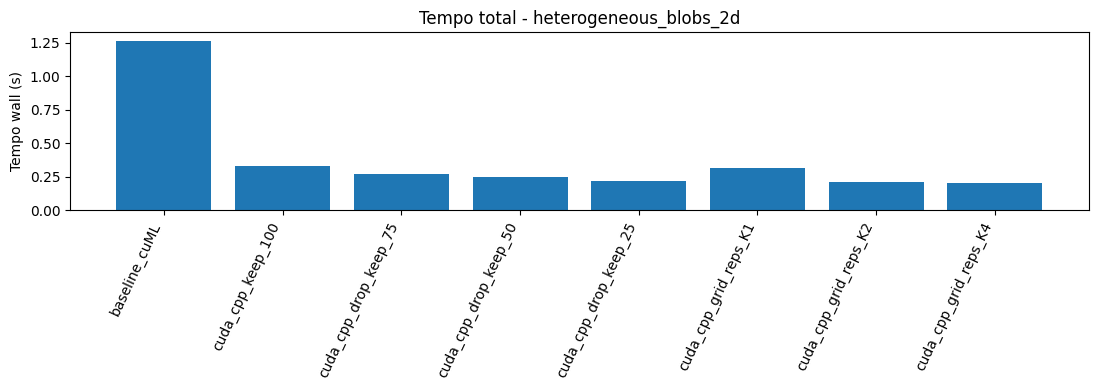

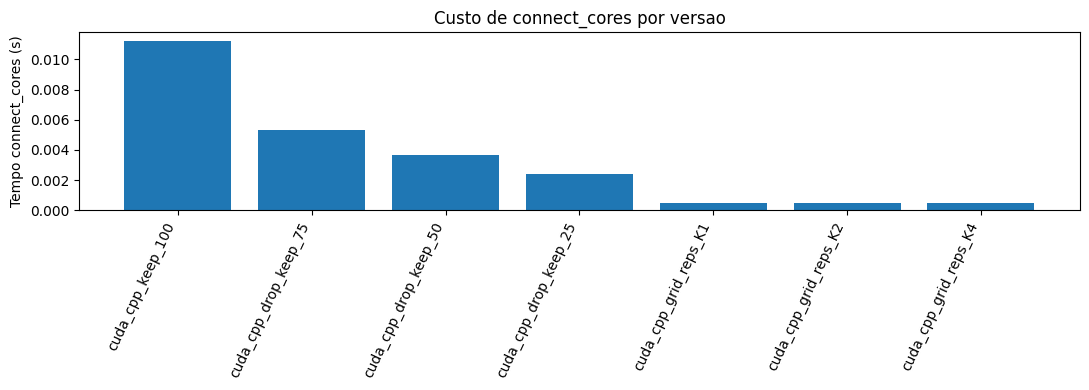

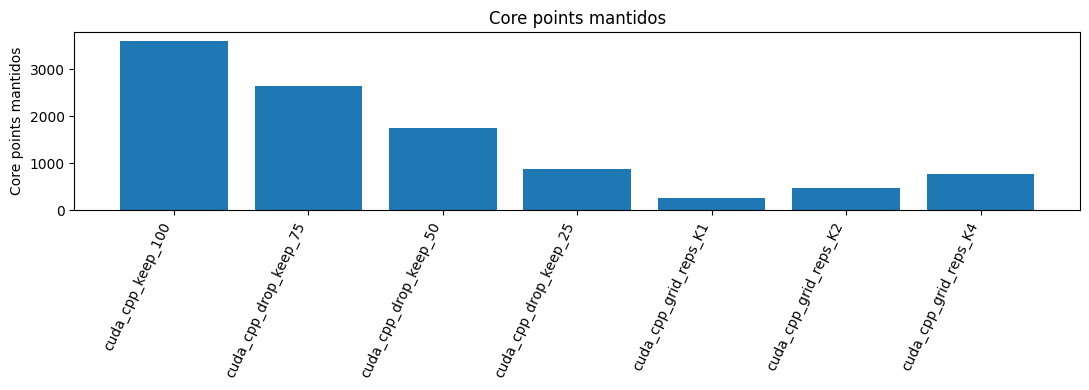

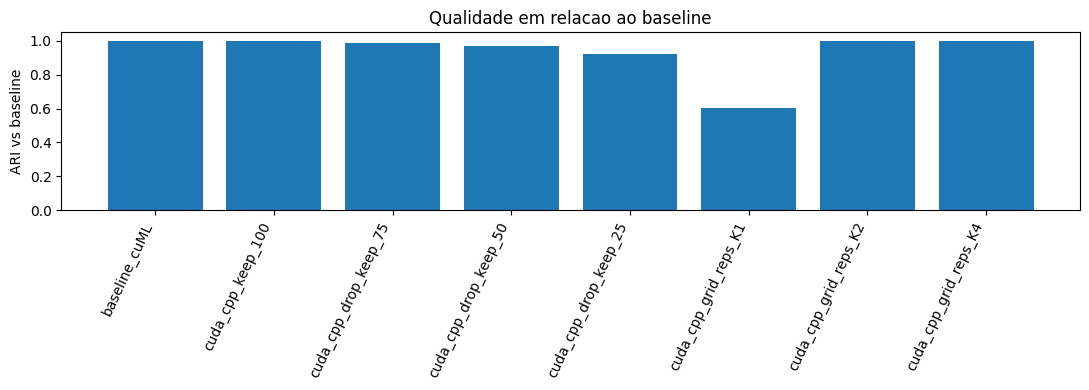

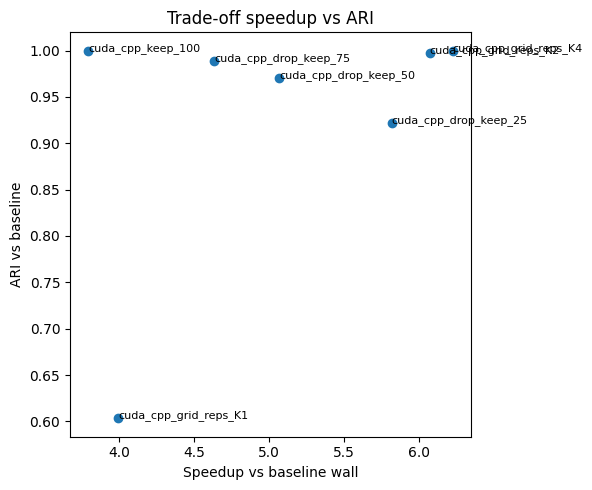

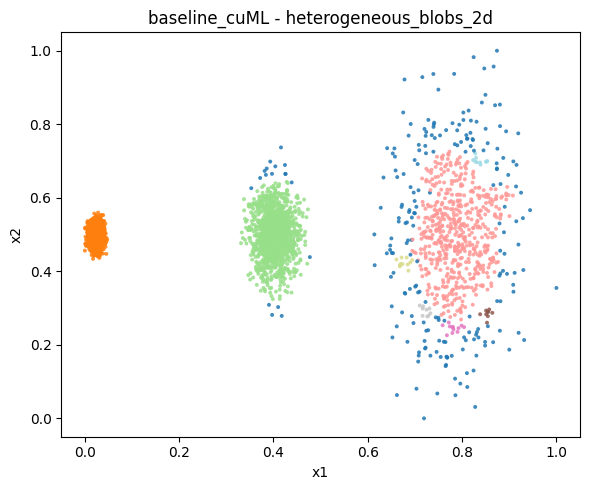

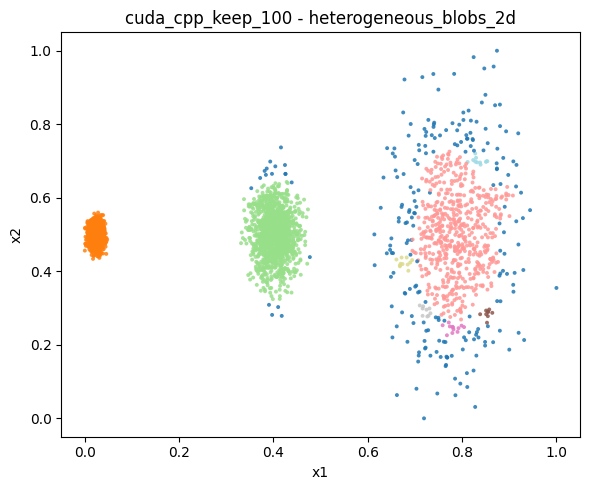

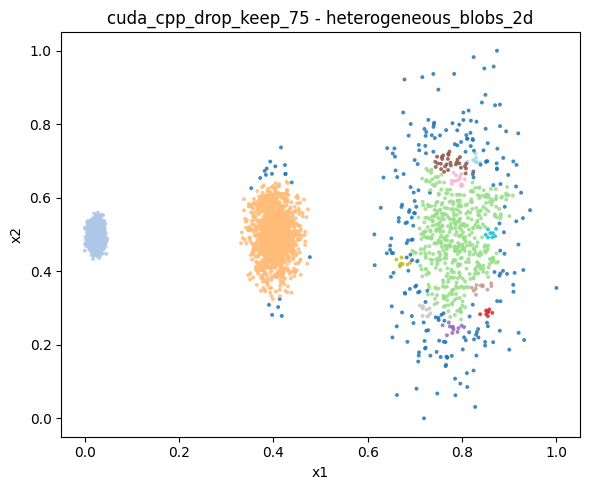

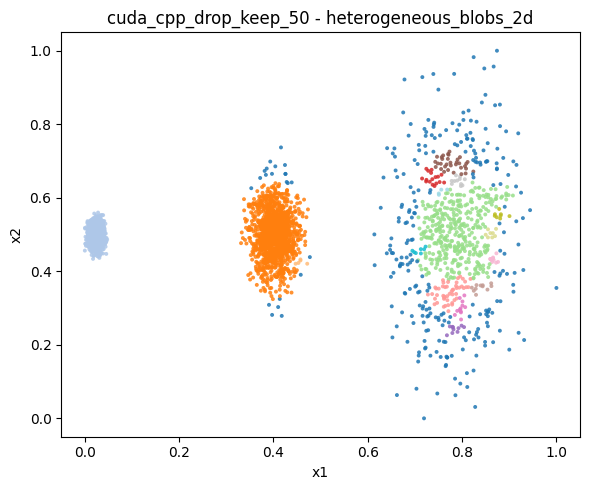

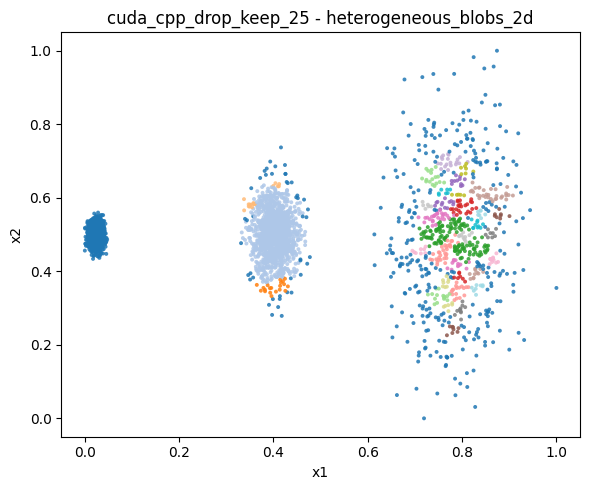

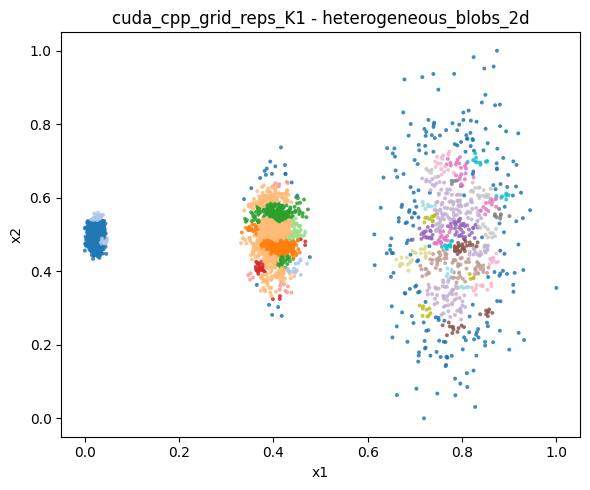

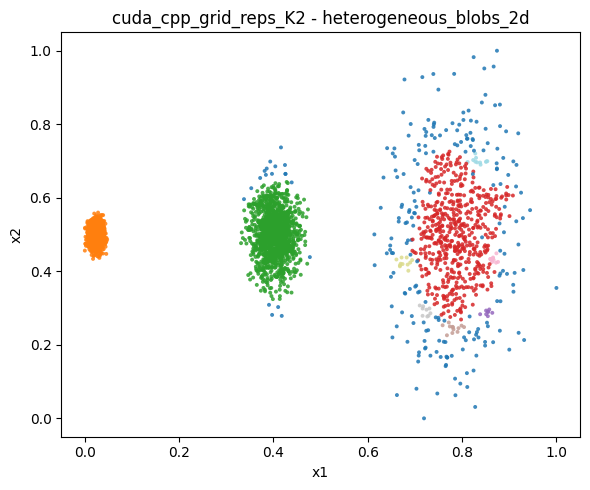

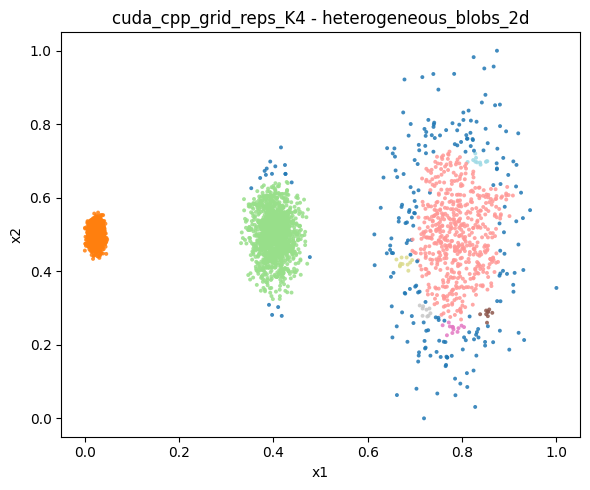

In [9]:
df_ok = df_results[df_results["status"] == "ok"].copy()
df_cuda = df_ok[df_ok["versao"].str.startswith("cuda_cpp")].copy()

plt.figure(figsize=(11, 4))
plt.bar(df_ok["versao"], df_ok["time_s_wall"])
plt.xticks(rotation=65, ha="right")
plt.ylabel("Tempo wall (s)")
plt.title(f"Tempo total - {DATASET_NAME}")
plt.tight_layout()
plt.show()

plt.figure(figsize=(11, 4))
plt.bar(df_cuda["versao"], df_cuda["time_connect"])
plt.xticks(rotation=65, ha="right")
plt.ylabel("Tempo connect_cores (s)")
plt.title("Custo de connect_cores por versao")
plt.tight_layout()
plt.show()

plt.figure(figsize=(11, 4))
plt.bar(df_cuda["versao"], df_cuda["kept_core_points"])
plt.xticks(rotation=65, ha="right")
plt.ylabel("Core points mantidos")
plt.title("Core points mantidos")
plt.tight_layout()
plt.show()

plt.figure(figsize=(11, 4))
plt.bar(df_ok["versao"], df_ok["ARI_vs_baseline"])
plt.xticks(rotation=65, ha="right")
plt.ylim(0, 1.05)
plt.ylabel("ARI vs baseline")
plt.title("Qualidade em relacao ao baseline")
plt.tight_layout()
plt.show()

plt.figure(figsize=(6, 5))
plt.scatter(df_cuda["speedup_vs_baseline_wall"], df_cuda["ARI_vs_baseline"])
for _, row in df_cuda.iterrows():
    plt.annotate(row["versao"], (row["speedup_vs_baseline_wall"], row["ARI_vs_baseline"]), fontsize=8)
plt.xlabel("Speedup vs baseline wall")
plt.ylabel("ARI vs baseline")
plt.title("Trade-off speedup vs ARI")
plt.tight_layout()
plt.show()

for name, labels in all_labels.items():
    plot_2d(X_plot, labels, f"{name} - {DATASET_NAME}")

In [10]:
# Opcional: rodar uma lista de datasets do manifest e consolidar resultados.
RUN_BATCH = False
BATCH_DATASETS = ["heterogeneous_blobs_2d", "dense_blobs_2d", "real_covtype_sample"]
BATCH_N_SAMPLES = [10000]

if RUN_BATCH:
    dfs = []
    for ds in BATCH_DATASETS:
        for ns in BATCH_N_SAMPLES:
            try:
                df_one, _, _ = executar_drop_core_dataset(ds, ns)
                dfs.append(df_one)
            except Exception as exc:
                dfs.append(pd.DataFrame([{"dataset_name": ds, "n_samples": ns, "versao": "drop_core", "status": "falhou", "motivo": str(exc)[:180]}]))
    df_batch = pd.concat(dfs, ignore_index=True)
    batch_csv = RESULTS_DIR / "resultados_drop_core_points_consolidado.csv"
    df_batch.to_csv(batch_csv, index=False)
    display(df_batch)
    print("CSV consolidado salvo em:", batch_csv)